# INVERTER CIRCUIT 32nm bulk CMOS

> Dataset source repository: https://github.com/GabriellJacinto/Electrical-Behaviour-Prediction
> Dataset Path: Electrical-Behaviour-Prediction/CMOS/32nm/NOT/Models/simu0/Advanced_Algorithms.ipynb

<small>

I'm using simu_0/treated_data dataset in this analysis

**Joined_data.csv:** contém os resultados brutos das simulações elétricas feitas no hspice (Monte Carlo).

**Treated_data.csv:** contém widths, tensões e temperaturas mapeadas.

O notebook advanced_algorithms usa o joined_data e depois gera o treated_data.

*No entanto, ainda não descobri a diferença entre simulação0 e simulação1. Estou usando a simul0.*

</small>

# Data exploration
Outliers were already removed in 01_data_cleaning

In [90]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [91]:
dataset_path = "/home/eduarda/Repos/jupyter_ic/data/processed/CMOS/32nm/NOT/01_data_cleaning/cmos_df.csv"
plots_dir = "/home/eduarda/Repos/jupyter_ic/figures/CMOS/32nm/NOT/02_data_exploration_plots"
df = pd.read_csv(dataset_path, index_col=0)

## Dataset

Inputs (7 total)
x = [nmos@var, pmos@var, temper, voltage, width_nmos, width_pmos, length]

Outputs (3 total)
y = [tphl, tplh, energy]

Variables (10 total)

- **nmos@var**: NMOS transistor process variation
- **pmos@var**: PMOS transistor process variation
- **tphl**:	propagation delay from output High to Low
- **tplh**: propagation delay from output Low to High
- **energy**:	energy dissipated by the circuit
- **temper**: operating temperature of the circuit
- **voltage**: supply voltage (VDD)
- **width_pmos**: width W of the PMOS transistor
- **width_nmos**: width W of the NMOS transistor
- **length_n&p**: channel length L of the NMOS and PMOS transistors

Units
- **nmos@var**: Volts (V)
- **pmos@var**: Volts (V)
- **tphl**:	Seconds (s)
- **tplh**: Seconds (s)
- **energy**:	Joules (J)
- **temper**: Celsius (°C)
- **voltage**: Volts (V)
- **width_pmos**: Meters (m)
- **width_nmos**: Meters (m)
- **length_n&p**: Meters (m)

There aren't fixed variables values.

- **nmos@var**: Existem 513 valores diferentes
- **pmos@var**:	Existem 489 valores diferentes
- **tphl**:	Existem 8200 valores diferentes
- **tplh**:	Existem 10430 valores diferentes
- **energy**:	Existem 14040 valores diferentes
- **temper**:	Existem 6 temperaturas diferentes
- **voltage**:	Existem 4 tensões diferentes
- **width_pmos**:	Existem 5 larguras diferentes
- **width_nmos**:	Existem 2 larguras diferentes
- **length_n&p**: Existem 3 valores diferentes


In [92]:
df.info()

<class 'pandas.DataFrame'>
Index: 127771 entries, 0 to 167999
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   PV_nmos      127771 non-null  float64
 1   PV_pmos      127771 non-null  float64
 2   temperature  127771 non-null  float64
 3   voltage      127771 non-null  float64
 4   W NMOS       127771 non-null  float64
 5   W PMOS       127771 non-null  float64
 6   L            127771 non-null  float64
 7   tphl         127771 non-null  float64
 8   tplh         127771 non-null  float64
 9   energy       127771 non-null  float64
dtypes: float64(10)
memory usage: 10.7 MB


**Checking if there're null values, how many different values in each variable and type**

In [93]:
df.isnull().sum()

PV_nmos        0
PV_pmos        0
temperature    0
voltage        0
W NMOS         0
W PMOS         0
L              0
tphl           0
tplh           0
energy         0
dtype: int64

There're only numerical variables.

In [94]:
df.size

1277710

In [95]:
df.shape

(127771, 10)

In [96]:
df.nunique()

PV_nmos          513
PV_pmos          489
temperature        6
voltage            4
W NMOS             2
W PMOS             5
L                  2
tphl            5009
tplh           10100
energy          3718
dtype: int64

In [97]:
df.describe(include="all")

,PV_nmos,PV_pmos,temperature,voltage,W NMOS,W PMOS,L,tphl,tplh,energy
count,127771.000000,127771.000000,127771.000000,127771.000000,1.277710e+05,1.277710e+05,1.277710e+05,1.277710e+05,1.277710e+05,1.277710e+05
mean,0.509723,-0.451149,32.301735,0.749356,7.819810e-08,2.164066e-07,3.349893e-08,1.291333e-11,1.577203e-11,-1.685973e-15
std,0.016645,0.015210,41.687904,0.107559,2.250916e-08,1.204728e-07,3.121656e-09,3.385645e-12,9.954472e-12,4.944592e-16
min,0.461300,-0.493300,-25.000000,0.600000,7.000000e-08,7.000000e-08,3.200000e-08,6.351000e-12,4.125000e-12,-3.000000e-15
25%,0.498500,-0.462200,0.000000,0.700000,7.000000e-08,1.400000e-07,3.200000e-08,1.036000e-11,8.464000e-12,-1.979000e-15
50%,0.509500,-0.450900,25.000000,0.700000,7.000000e-08,1.400000e-07,3.200000e-08,1.248000e-11,1.277000e-11,-1.579000e-15
75%,0.520700,-0.440600,75.000000,0.800000,7.000000e-08,3.500000e-07,3.200000e-08,1.492000e-11,2.024000e-11,-1.317000e-15
max,0.586100,-0.405800,100.000000,0.900000,1.400000e-07,4.200000e-07,4.000000e-08,2.898000e-11,6.720000e-11,-7.993000e-16


In [98]:
df.isnull().sum()

PV_nmos        0
PV_pmos        0
temperature    0
voltage        0
W NMOS         0
W PMOS         0
L              0
tphl           0
tplh           0
energy         0
dtype: int64

As we've seen before, there is no null values.

The dataset is composed only of quantitative (numerical) variables, there's none categorical (non-numerical) variables

#### Frequency of output item

In [99]:
df['tphl'].value_counts()

tphl
1.242000e-11    200
1.197000e-11    199
1.189000e-11    196
1.006000e-11    195
1.235000e-11    191
               ... 
7.822000e-12      1
8.745000e-12      1
8.620000e-12      1
8.494000e-12      1
8.444000e-12      1
Name: count, Length: 5009, dtype: int64

In [100]:
df['tplh'].value_counts()

tplh
1.032000e-11    122
1.033000e-11    120
1.003000e-11    117
1.007000e-11    116
1.038000e-11    111
               ... 
7.147000e-12      1
7.345000e-12      1
7.112000e-12      1
9.755000e-12      1
3.359000e-11      1
Name: count, Length: 10100, dtype: int64

In [101]:
df['energy'].value_counts()

energy
-1.556000e-15    246
-1.553000e-15    239
-1.551000e-15    237
-1.604000e-15    237
-1.550000e-15    234
                ... 
-9.819000e-16      1
-9.838000e-16      1
-9.765000e-16      1
-9.758000e-16      1
-9.884000e-16      1
Name: count, Length: 3718, dtype: int64

In [102]:
df.describe()

,PV_nmos,PV_pmos,temperature,voltage,W NMOS,W PMOS,L,tphl,tplh,energy
count,127771.000000,127771.000000,127771.000000,127771.000000,1.277710e+05,1.277710e+05,1.277710e+05,1.277710e+05,1.277710e+05,1.277710e+05
mean,0.509723,-0.451149,32.301735,0.749356,7.819810e-08,2.164066e-07,3.349893e-08,1.291333e-11,1.577203e-11,-1.685973e-15
std,0.016645,0.015210,41.687904,0.107559,2.250916e-08,1.204728e-07,3.121656e-09,3.385645e-12,9.954472e-12,4.944592e-16
min,0.461300,-0.493300,-25.000000,0.600000,7.000000e-08,7.000000e-08,3.200000e-08,6.351000e-12,4.125000e-12,-3.000000e-15
25%,0.498500,-0.462200,0.000000,0.700000,7.000000e-08,1.400000e-07,3.200000e-08,1.036000e-11,8.464000e-12,-1.979000e-15
50%,0.509500,-0.450900,25.000000,0.700000,7.000000e-08,1.400000e-07,3.200000e-08,1.248000e-11,1.277000e-11,-1.579000e-15
75%,0.520700,-0.440600,75.000000,0.800000,7.000000e-08,3.500000e-07,3.200000e-08,1.492000e-11,2.024000e-11,-1.317000e-15
max,0.586100,-0.405800,100.000000,0.900000,1.400000e-07,4.200000e-07,4.000000e-08,2.898000e-11,6.720000e-11,-7.993000e-16


In [103]:
output_vars = ['tphl', 'tplh', 'energy']

variance_results = df[output_vars].var()
std_dev_results = df[output_vars].std()

eda_summary = pd.DataFrame({
    'Variance': variance_results,
    'Standard Deviation': std_dev_results
})

print(eda_summary)

            Variance  Standard Deviation
tphl    1.146259e-23        3.385645e-12
tplh    9.909152e-23        9.954472e-12
energy  2.444899e-31        4.944592e-16


In [104]:
df.corr()

,PV_nmos,PV_pmos,temperature,voltage,W NMOS,W PMOS,L,tphl,tplh,energy
PV_nmos,1.000000,0.034806,0.038418,0.002917,0.032598,0.034796,-0.022720,0.174995,-0.022641,0.112036
PV_pmos,0.034806,1.000000,-0.023705,-0.001645,-0.019272,-0.031196,0.014684,0.014604,-0.070825,-0.053504
temperature,0.038418,-0.023705,1.000000,-0.007740,-0.130118,-0.139460,0.058240,0.461049,0.520156,-0.422117
voltage,0.002917,-0.001645,-0.007740,1.000000,-0.015177,-0.010176,0.003433,-0.112415,-0.055632,-0.076660
W NMOS,0.032598,-0.019272,-0.130118,-0.015177,1.000000,0.615506,-0.174886,-0.410514,-0.288699,-0.300066
W PMOS,0.034796,-0.031196,-0.139460,-0.010176,0.615506,1.000000,-0.304539,0.028063,-0.696719,-0.434837
L,-0.022720,0.014684,0.058240,0.003433,-0.174886,-0.304539,1.000000,0.232621,0.123447,0.201189
tphl,0.174995,0.014604,0.461049,-0.112415,-0.410514,0.028063,0.232621,1.000000,0.238986,0.209867
tplh,-0.022641,-0.070825,0.520156,-0.055632,-0.288699,-0.696719,0.123447,0.238986,1.000000,0.264389
energy,0.112036,-0.053504,-0.422117,-0.076660,-0.300066,-0.434837,0.201189,0.209867,0.264389,1.000000


## Exploratory Data Plots

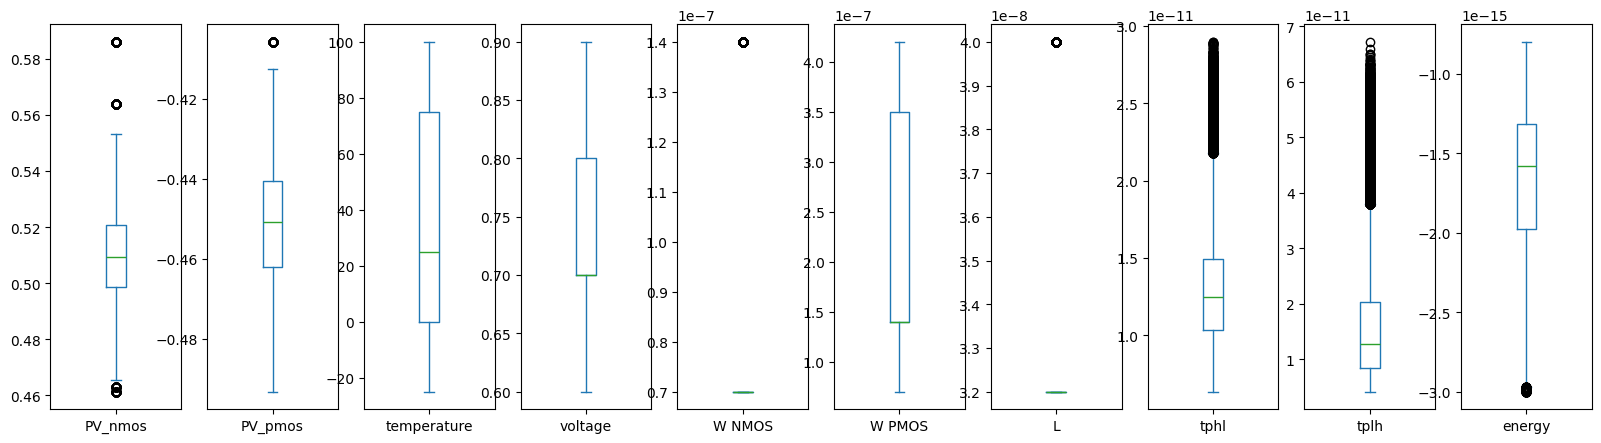

<Figure size 640x480 with 0 Axes>

In [105]:
df.plot(kind='box', figsize=(30, 5), subplots=True, layout=(1, 15))
plt.figure()
plt.show()
plt.close()

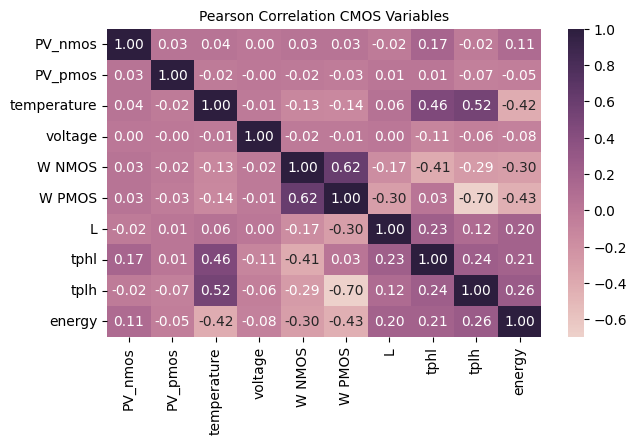

In [106]:
# Correlation
plt.figure(figsize=(7, 4))
ax = sns.heatmap(df.corr(method='pearson', numeric_only=True), 
                annot=True, fmt=".2f",
                cmap=sns.cubehelix_palette(as_cmap=True))
ax.set_title('Pearson Correlation CMOS Variables', fontsize=10)
ax=ax
plt.savefig(f"{plots_dir}/cmos_correlation.png", bbox_inches='tight', dpi=300)
plt.show()
plt.close()

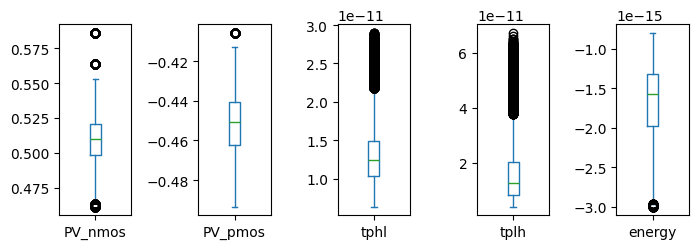

In [107]:
variables = ['temperature', 'voltage', 'W PMOS', 'W NMOS', 'L']
cols = [c for c in df.columns if 'length' not in c.lower() and c not in variables]
axes = df[cols].plot(kind='box', figsize=(7, 2.6), subplots=True, layout=(1, len(cols)))

plt.tight_layout()
plt.savefig(f"{plots_dir}/cmos_boxplot.png", bbox_inches='tight')
plt.show()
plt.close()

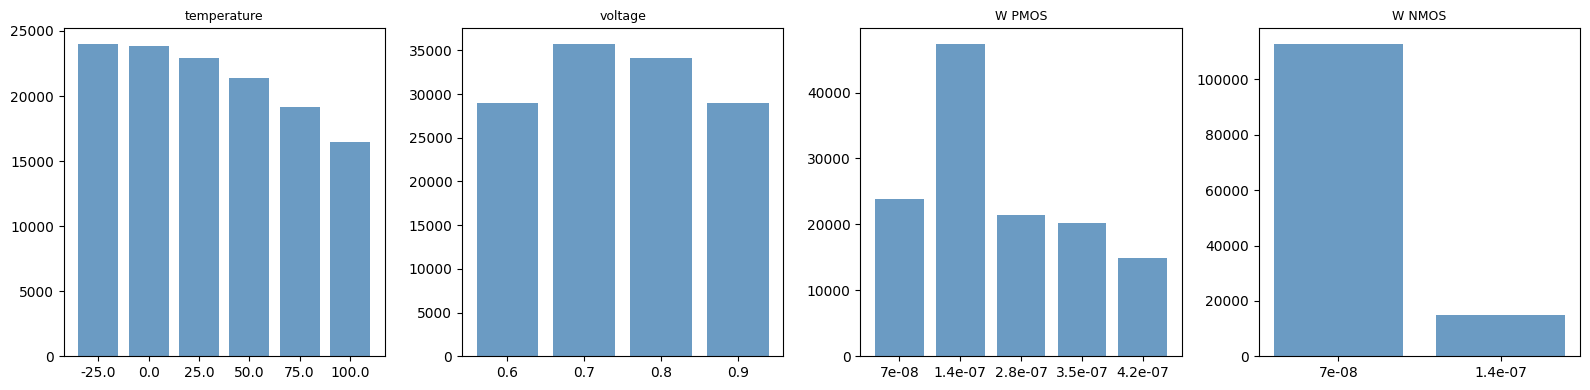

In [108]:
cols = ['temperature', 'voltage', 'W PMOS', 'W NMOS']
fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(16, 4))

for i, col in enumerate(cols):
    counts = df[col].value_counts().sort_index()
    axes[i].bar(counts.index.astype(str), counts.values, color='steelblue', alpha=0.8)
    axes[i].set_title(col, fontsize=9)

plt.tight_layout()
plt.savefig(f"{plots_dir}/cmos_count_plot.png")
plt.show()
plt.close()

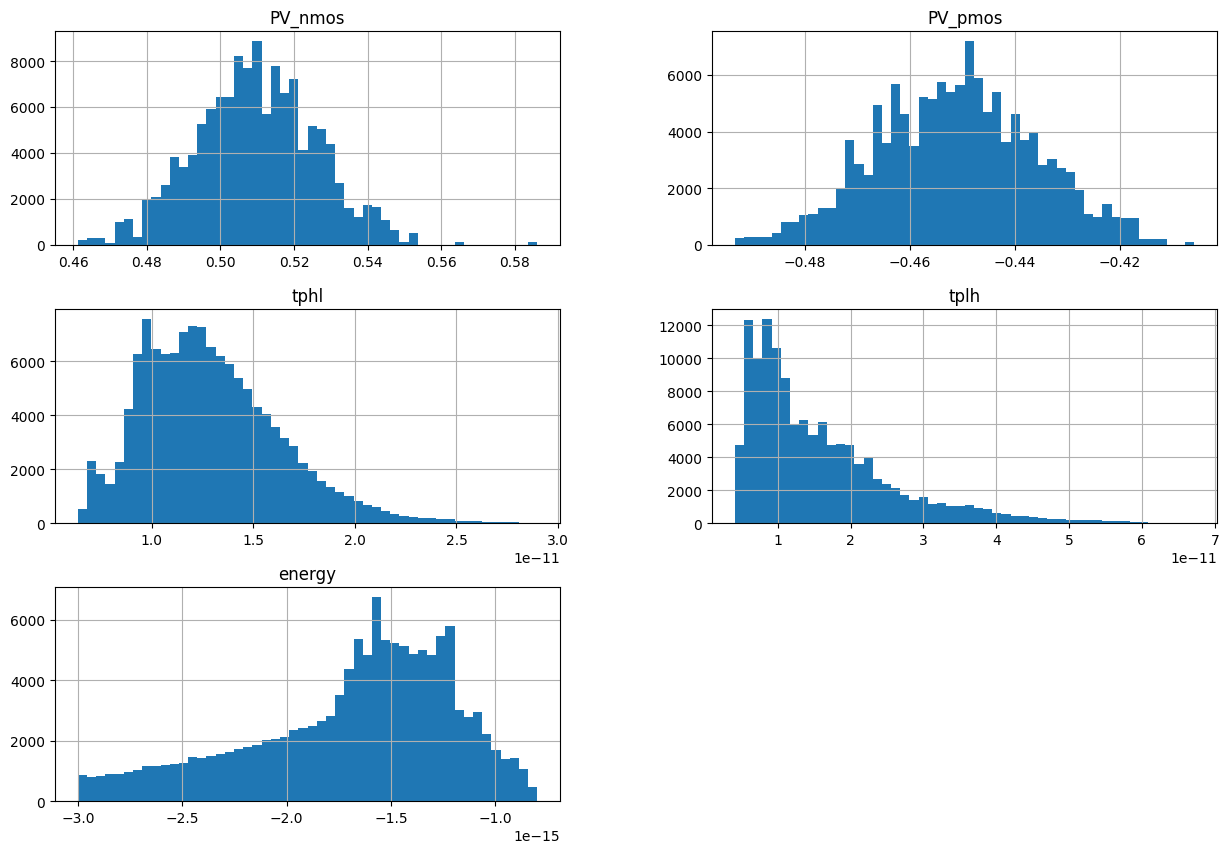

In [109]:
df[['PV_nmos', 'PV_pmos', 'tphl', 'tplh', 'energy']].hist(
    bins=50, 
    figsize=(15, 10), 
    layout=(3, 2)
)
    
plt.savefig(f"{plots_dir}/cmos_histogram.png")
plt.show()
plt.close()

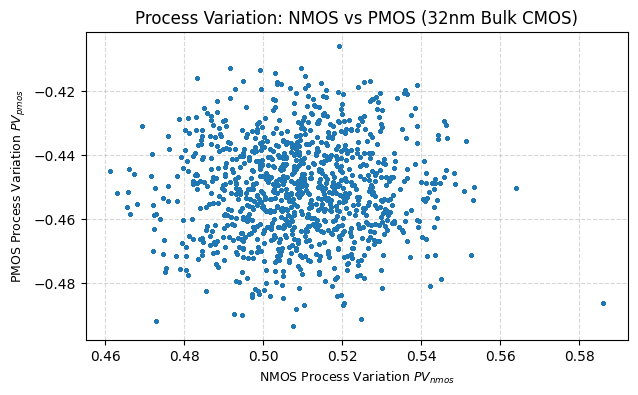

In [110]:
fig, ax = plt.subplots(figsize=(7, 4))
plt.plot('PV_nmos', 'PV_pmos', data=df, linestyle='none', marker='D', markersize=2)
plt.title('Process Variation: NMOS vs PMOS (32nm Bulk CMOS)')
plt.xlabel('NMOS Process Variation $PV_{nmos}$', fontsize=9)
plt.ylabel('PMOS Process Variation $PV_{pmos}$', fontsize=9)
ax.grid(True, linestyle='--', alpha=0.5)
plt.savefig(f"{plots_dir}/cmos_scatter_plot.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()

In [111]:
df.to_csv('/home/eduarda/Repos/jupyter_ic/data/processed/CMOS/32nm/NOT/02_data_exploration/cmos_df.csv', index=True)